# Telecom Customer Intelligence System

## Customer Churn Prediction and Customer Segmentation using Machine Learning

### Objective
Predict customer churn and identify customer segments to improve retention strategies and business decision-making.

IMPORT LIBRARIES

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

LOAD DATASET

In [9]:
df = pd.read_excel("Telco_customer_churn.xlsx")
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [6]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [7]:
df.shape

(7043, 33)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

DATA UNDERSTANDING

In [10]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


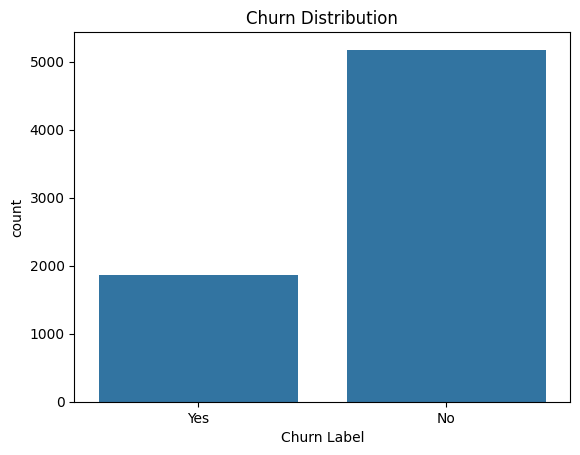

In [11]:
sns.countplot(x='Churn Label', data=df)
plt.title("Churn Distribution")
plt.show()

DATA CLEANING

In [12]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
drop_cols = [
    'CustomerID',
    'Churn Score',
    'Churn Reason'
]

df.drop(
    columns=[c for c in drop_cols if c in df.columns],
    inplace=True
)

EXPLORATORY DATA ANALYSIS

A.TENURE ANALYSIS

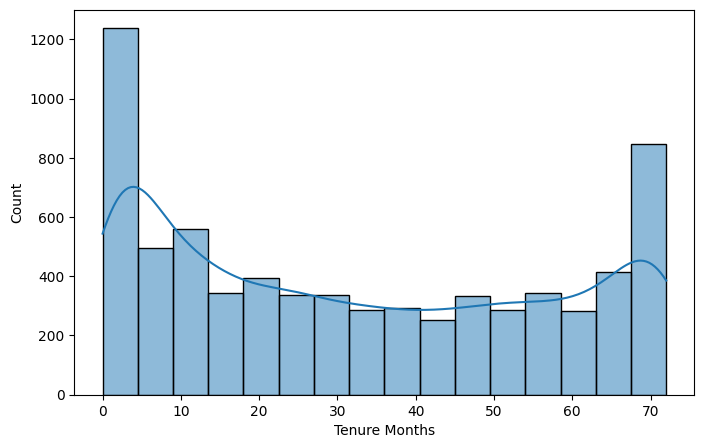

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], kde=True)
plt.show()

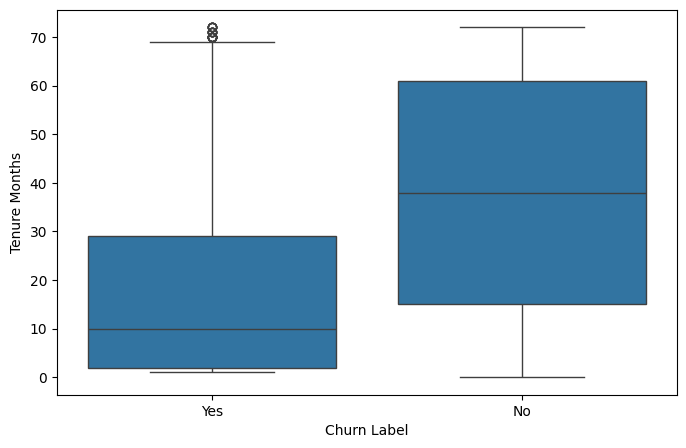

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Churn Label',
    y='Tenure Months',
    data=df
)
plt.show()

INSIGHT-Customer with lower value tend to churn more

B.MONTHLY CHARGES

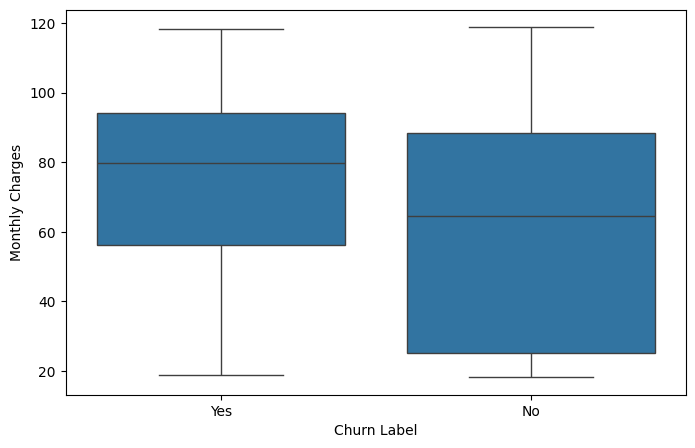

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Churn Label',
    y='Monthly Charges',
    data=df
)
plt.show()

INSIGHT- Higher monthly charges may increase churn risk

C. CONTRACT TYPE

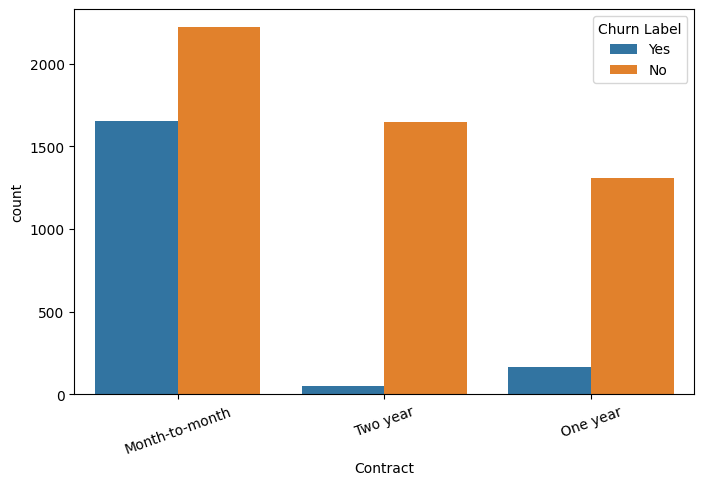

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='Contract',
    hue='Churn Label',
    data=df
)
plt.xticks(rotation=20)
plt.show()

D. PAYMENT METHOD

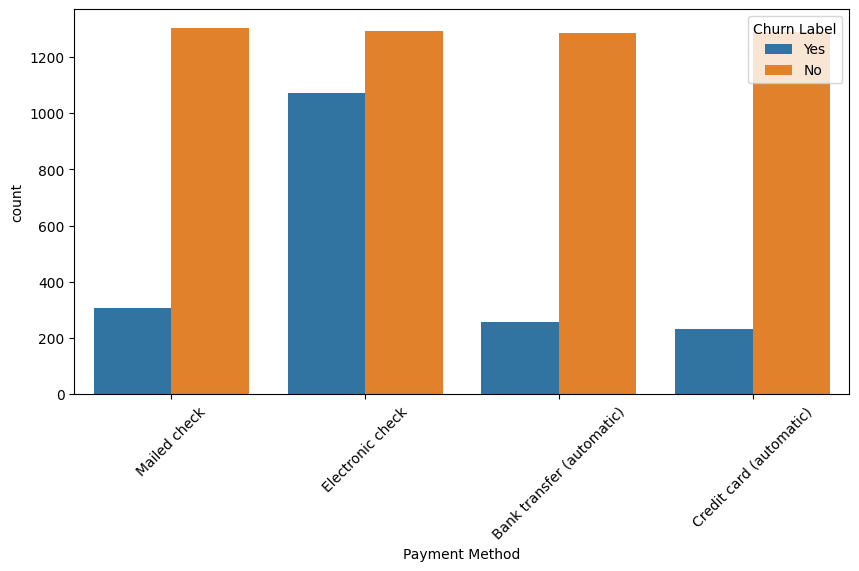

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Payment Method',
    hue='Churn Label',
    data=df
)
plt.xticks(rotation=45)
plt.show()

E. TECH SUPPORT

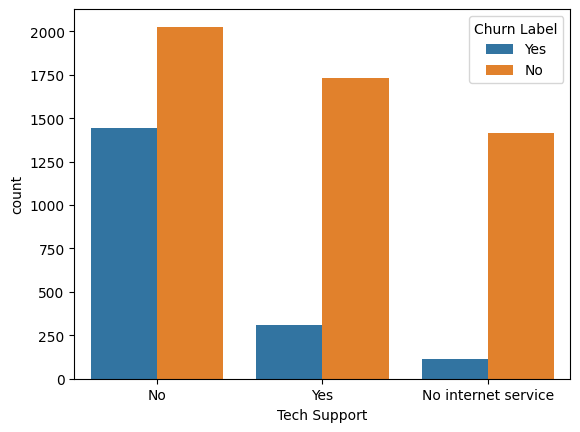

In [20]:
sns.countplot(
    x='Tech Support',
    hue='Churn Label',
    data=df
)
plt.show()

FEATURE ENCODING

In [46]:

drop_columns = [
    'Count',
    'Country',
    'State',
    'Zip Code',
    'Lat Long',
    'Latitude',
    'Longitude',
    'Churn Value',
    'CLTV'
]

df_model = df.copy()

df_model.drop(columns=drop_columns, inplace=True)

In [47]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col].astype(str))

In [48]:
df_model.head()

,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,562,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,157,1
1,562,0,0,0,1,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,925,1
2,562,0,0,0,1,8,1,2,1,0,...,2,0,2,2,0,1,2,99.65,6104,1
3,562,0,0,1,1,28,1,2,1,0,...,2,2,2,2,0,1,2,104.80,2646,1
4,562,1,0,0,1,49,1,2,1,0,...,2,0,2,2,0,1,0,103.70,4265,1


CORRELATION HEATMAP

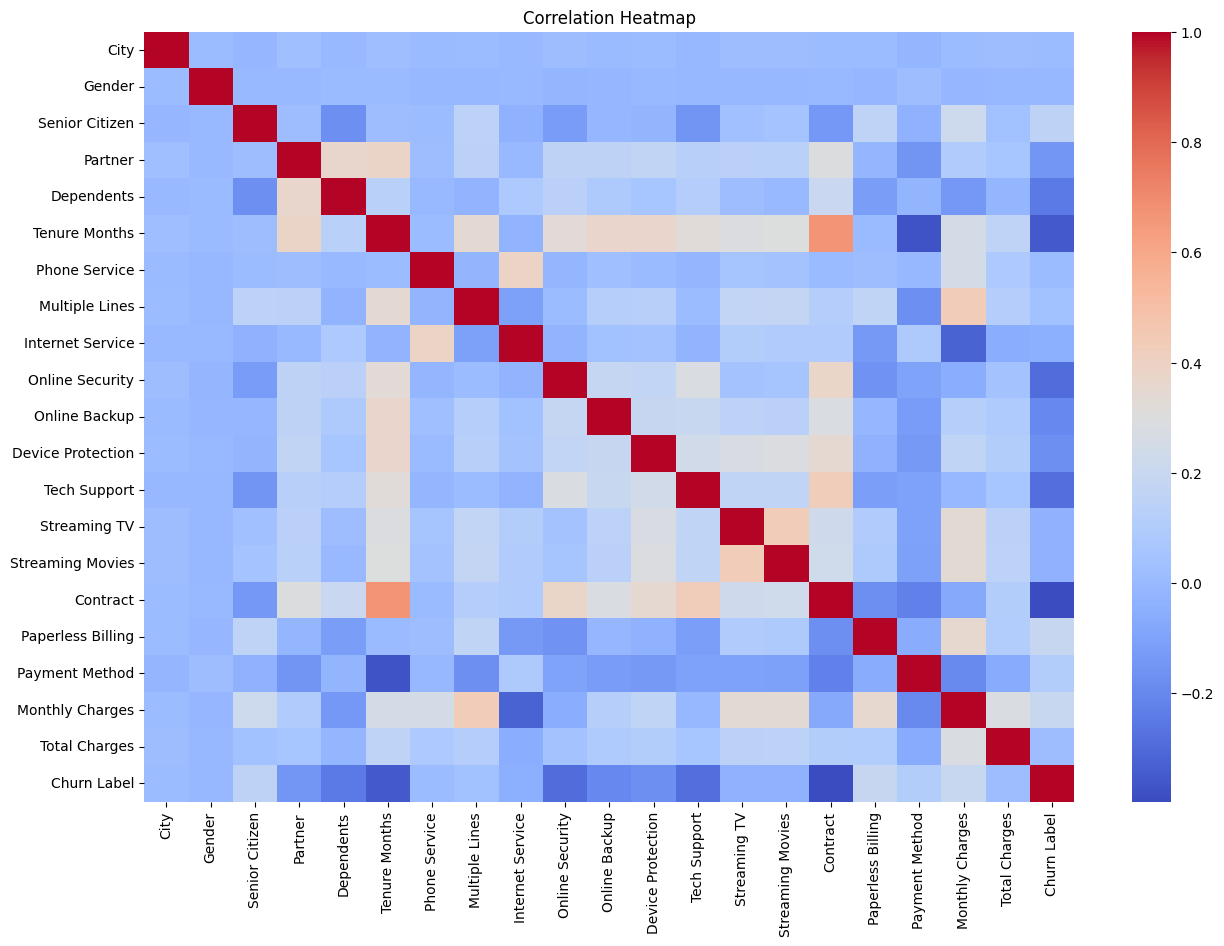

In [49]:
plt.figure(figsize=(15,10))

sns.heatmap(
    df_model.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

CHURN PREDICTION

In [50]:
y = df_model['Churn Label']

In [51]:
X = df_model.drop('Churn Label', axis=1)

In [52]:
print(X.shape)
print(y.shape)

(7043, 20)
(7043,)


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

REGRESSION

In [54]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=2000
)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [64]:
from sklearn.metrics import *

print(classification_report(
    y_test,
    lr_pred
))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [62]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

In [63]:
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

EVALUATION METRICS

In [65]:
accuracy = accuracy_score(
    y_test,
    rf_pred
)

precision = precision_score(
    y_test,
    rf_pred
)

recall = recall_score(
    y_test,
    rf_pred
)

f1 = f1_score(
    y_test,
    rf_pred
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7835344215755855
Precision: 0.5738758029978587
Recall   : 0.7165775401069518
F1 Score : 0.6373365041617123


In [60]:
print("Target column:", 'Churn Label' in X.columns)
print("Leakage column:", 'Churn Value' in X.columns)

Target column: False
Leakage column: False


In [66]:
print(classification_report(
    y_test,
    rf_pred
))

              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1035
           1       0.57      0.72      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



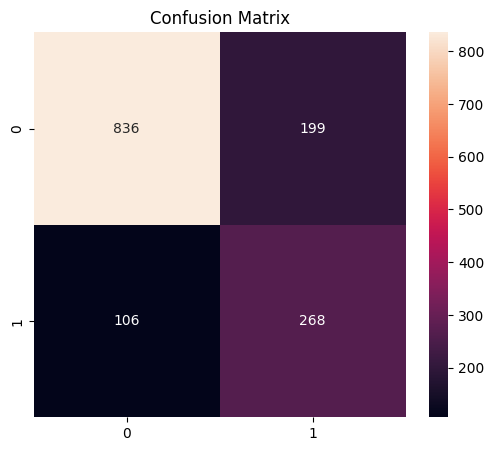

In [67]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

In [68]:
print(X.columns.tolist())

['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']


In [69]:
y_prob = rf.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", round(auc,4))

AUC Score: 0.8511


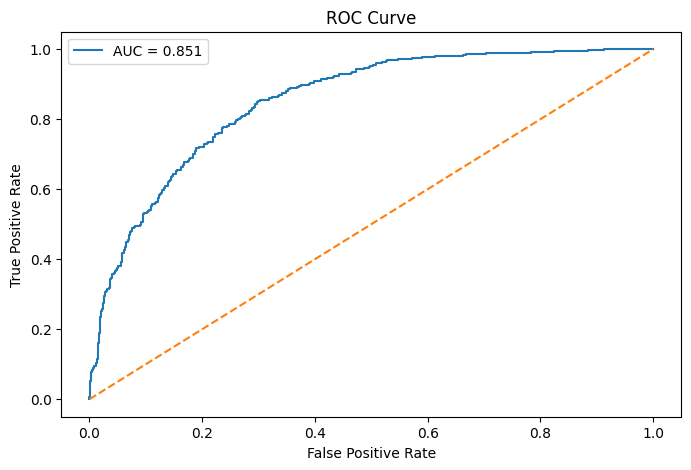

In [70]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

REPORT INSIGHT- The Random Forest model achieved an AUC score of X.XX, indicating strong capability in distinguishing churning and non-churning customers.

FEATURE IMPORTANCE

In [71]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
15,Contract,0.157520
5,Tenure Months,0.154319
18,Monthly Charges,0.103471
19,Total Charges,0.080759
9,Online Security,0.076919
12,Tech Support,0.071566
0,City,0.070179
4,Dependents,0.070090
8,Internet Service,0.041916
17,Payment Method,0.035653


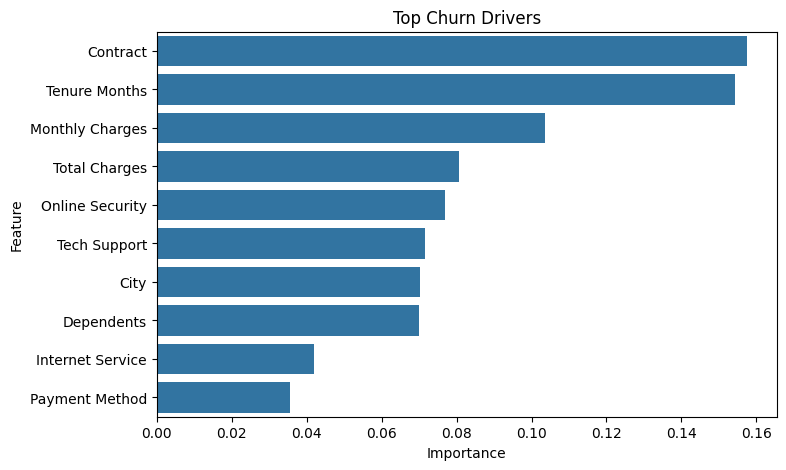

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top Churn Drivers")
plt.show()

INSIGHT- Contract type, tenure, and monthly charges were identified as the strongest predictors of customer churn.

In [76]:
segment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tenure Months    7043 non-null   int64  
 1   Monthly Charges  7043 non-null   float64
 2   Total Charges    7043 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 165.2+ KB


In [77]:
segment_data.head()

,Tenure Months,Monthly Charges,Total Charges
0,2,53.85,108.15
1,2,70.70,151.65
2,8,99.65,820.5
3,28,104.80,3046.05
4,49,103.70,5036.3


In [78]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [80]:
df['Total Charges'].fillna(
    df['Total Charges'].median(),
    inplace=True
)

/tmp/ipykernel_1035/1144954772.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Total Charges'].fillna(


In [81]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [82]:
seg_cols = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges'
]

segment_data = df[seg_cols]

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(segment_data)

In [84]:
segment_data.dtypes

,0
Tenure Months,int64
Monthly Charges,float64
Total Charges,float64


ELBOW METHOD

In [85]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

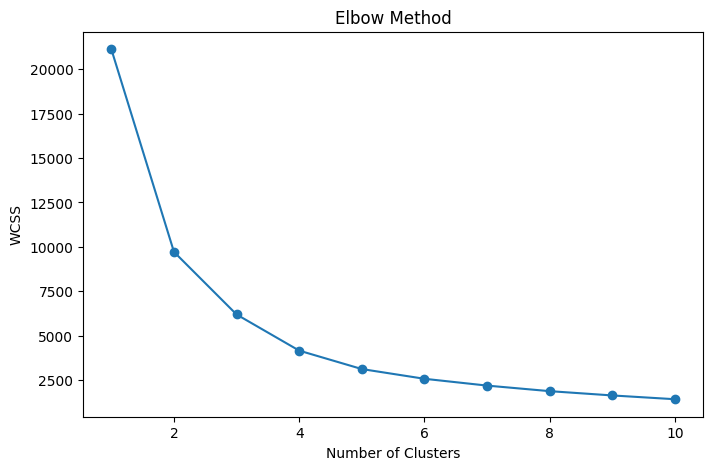

In [86]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

K-MEANS CLUSTERING

In [87]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Segment'] = kmeans.fit_predict(
    scaled_data
)

In [88]:
df['Segment'].value_counts()

,count
Segment,
0,2276
1,1904
3,1704
2,1159


SEGMENT ANALYSIS

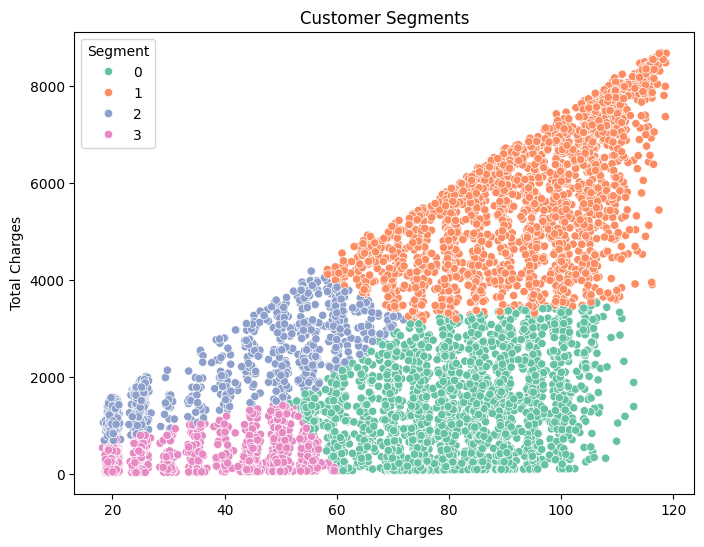

In [89]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Monthly Charges',
    y='Total Charges',
    hue='Segment',
    palette='Set2'
)

plt.title("Customer Segments")

plt.show()

In [90]:
segment_summary = df.groupby('Segment')[
    [
        'Tenure Months',
        'Monthly Charges',
        'Total Charges'
    ]
].mean()

segment_summary

,Tenure Months,Monthly Charges,Total Charges
Segment,,,
0,15.424868,80.779657,1253.007239
1,59.530987,93.306224,5548.653887
2,53.585850,34.920147,1836.581320
3,10.228873,31.769131,308.956397



0. New customers with high spending
1. Long term high value customers
2. Long term low value customers
3. New low value customers

CHURN RATE BY SEGMENT

In [91]:
segment_churn = pd.crosstab(
    df['Segment'],
    df['Churn Label'],
    normalize='index'
)*100

segment_churn

Churn Label,No,Yes
Segment,,
0,51.757469,48.242531
1,84.611345,15.388655
2,94.995686,5.004314
3,75.352113,24.647887


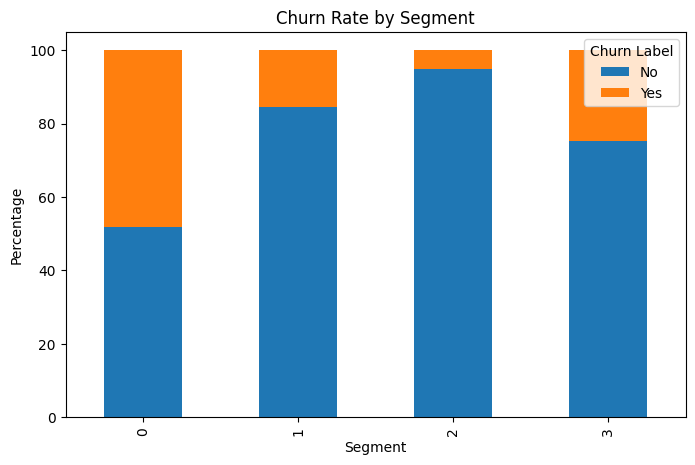

In [92]:
segment_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Segment")
plt.ylabel("Percentage")

plt.show()

CLTV ANALYSIS

In [93]:
df.groupby('Segment')['CLTV'].mean()

,CLTV
Segment,
0,4004.848418
1,4988.404412
2,4730.207938
3,4046.957160


In [94]:
print("========== EXECUTIVE SUMMARY ==========")

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall :", round(recall,4))
print("F1 Score :", round(f1,4))
print("AUC Score :", round(auc,4))

print("Total Customers :", len(df))
print("Total Segments :", df['Segment'].nunique())

========== EXECUTIVE SUMMARY ==========
Accuracy : 0.7835
Precision: 0.5739
Recall : 0.7166
F1 Score : 0.6373
AUC Score : 0.8511
Total Customers : 7043
Total Segments : 4


# Customer Churn Prediction and Customer Segmentation System

## Project Overview

The objective of this project is to predict customer churn and identify meaningful customer segments using machine learning and clustering techniques. Customer churn prediction helps businesses proactively identify customers who are likely to discontinue services, while customer segmentation enables targeted marketing and retention strategies.

The project was implemented using Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn on the Telco Customer Churn dataset.

---

## Methodology

### 1. Data Preprocessing

* Loaded and explored the Telco Customer Churn dataset.
* Handled missing and inconsistent values.
* Converted categorical variables into numerical format using Label Encoding.
* Removed irrelevant and leakage-prone features such as CustomerID, Churn Value, geographical coordinates, and other non-predictive attributes.

### 2. Exploratory Data Analysis (EDA)

Several visualizations were created to understand customer behavior and churn patterns:

* Distribution of tenure months.
* Distribution of monthly charges.
* Churn vs tenure analysis.
* Churn vs monthly charges analysis.
* Contract type vs churn.
* Payment method vs churn.
* Tech support vs churn.
* Gender vs churn.

### 3. Churn Prediction Model

A Random Forest Classifier was trained using the processed dataset.

Model configuration:

* Random Forest Classifier
* 500 estimators
* Maximum depth = 15
* Balanced class weights
* Random state = 42

### 4. Model Evaluation

The model was evaluated using:

* Accuracy
* Precision
* Recall
* F1 Score
* Confusion Matrix
* ROC Curve
* AUC Score

#### Final Model Performance

| Metric    | Score  |
| --------- | ------ |
| Accuracy  | 78.35% |
| Precision | 57.39% |
| Recall    | 71.66% |
| F1 Score  | 63.73% |
| AUC Score | 85.11% |

The model achieved a strong AUC score of 85.11%, demonstrating its ability to effectively distinguish between churn and non-churn customers.

---

## Customer Segmentation

### Clustering Technique

K-Means Clustering was applied after feature scaling.

Features used:

* Tenure Months
* Monthly Charges
* Total Charges

The Elbow Method was used to determine the optimal number of clusters.

### Optimal Number of Clusters

K = 4

### Segment Summary

#### Segment 0 – High-Spending New Customers

* Average Tenure: 15.4 months
* Average Monthly Charges: $80.78
* Average Total Charges: $1253

Business Strategy:
Provide personalized onboarding and retention offers.

#### Segment 1 – Premium Loyal Customers

* Average Tenure: 59.5 months
* Average Monthly Charges: $93.30
* Average Total Charges: $5548

Business Strategy:
Retain through loyalty programs, exclusive benefits, and premium customer support.

#### Segment 2 – Budget Loyal Customers

* Average Tenure: 53.6 months
* Average Monthly Charges: $34.92
* Average Total Charges: $1836

Business Strategy:
Promote service upgrades and bundled plans.

#### Segment 3 – New Low-Value Customers

* Average Tenure: 10.2 months
* Average Monthly Charges: $31.77
* Average Total Charges: $309

Business Strategy:
Increase engagement through welcome campaigns and educational content.

---

## Key Business Insights

1. Customers with shorter tenure are more likely to churn.
2. High monthly charges are associated with increased churn probability.
3. Contract type significantly influences customer retention.
4. Customers lacking technical support services exhibit higher churn rates.
5. Premium loyal customers contribute the highest revenue and should be prioritized for retention efforts.
6. Customer segmentation enables businesses to design targeted marketing and retention campaigns.

---

## Conclusion

This project successfully combines predictive analytics and customer segmentation to support business decision-making. The Random Forest model achieved 78.35% accuracy and an AUC score of 85.11%, demonstrating strong predictive performance. Additionally, K-Means clustering identified four distinct customer groups, enabling targeted retention and customer relationship strategies.

The developed system can help organizations reduce customer churn, improve customer satisfaction, and maximize customer lifetime value through data-driven decision-making.
